In [9]:
import arff
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [10]:
file_path = '../data/dataset.mat'

with open(file_path, 'r') as f:
    data_dict = arff.load(f)

# This restores 'df' to a Pandas DataFrame
df = pd.DataFrame(data_dict['data'])
df.columns = [attr[0] for attr in data_dict['attributes']]

print("DataFrame reloaded successfully!")
print(df.head())

DataFrame reloaded successfully!
   surname  creditscore   age  tenure    balance  numofproducts  hascrcard  \
0     2023        668.0  33.0     3.0       0.00            2.0          1   
1     2024        627.0  33.0     1.0       0.00            2.0          1   
2     1236        678.0  40.0    10.0       0.00            2.0          1   
3     1362        581.0  34.0     2.0  148882.54            1.0          1   
4      491        716.0  33.0     5.0       0.00            2.0          1   

   isactivemember  estimatedsalary exited  ...  france  germany  spain  \
0               0        181449.97      0  ...       1        0      0   
1               1         49503.50      0  ...       1        0      0   
2               0        184866.69      0  ...       1        0      0   
3               1         84560.88      0  ...       1        0      0   
4               1         15068.83      0  ...       0        0      1   

   female  male  mem__no__products  cred_bal_sal   ba

In [11]:
# 1. Separate your features (X) and target (y)
y = df['exited']
x = df.drop('exited', axis=1)

# 2. Select numerical columns from X
numerical_cols = x.select_dtypes(include=['float64', 'int64']).columns

# 3. Initialize and apply the scaler
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x[numerical_cols]), columns=numerical_cols)

# Check the result
print("\nScaling complete. Scaled features head:")
print(x_scaled.head())


Scaling complete. Scaled features head:
    surname  creditscore       age    tenure   balance  numofproducts  \
0  0.498295     0.146485 -0.576544 -0.718557 -0.899885       0.813766   
1  0.499524    -0.358765 -0.576544 -1.430010 -0.899885       0.813766   
2 -0.468714     0.269716  0.203875  1.771530 -0.899885       0.813766   
3 -0.313894    -0.925630 -0.465056 -1.074283  1.463996      -1.007031   
4 -1.384116     0.737996 -0.576544 -0.007103 -0.899885       0.813766   

   hascrcard  isactivemember  estimatedsalary  surname_tfidf_0  ...    france  \
0   0.575529       -0.997512         1.369413        -0.223256  ...  0.874043   
1   0.575529        1.002494        -1.227193        -0.223250  ...  0.874043   
2   0.575529       -0.997512         1.436651        -0.225852  ...  0.874043   
3   0.575529        1.002494        -0.537291        -0.223798  ...  0.874043   
4   0.575529        1.002494        -1.904841        -0.223254  ... -1.144109   

    germany     spain    female  

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [13]:
logistic_model = LogisticRegression(class_weight='balanced')
logistic_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
# Get predictions on the test data
y_pred = logistic_model.predict(x_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 75.07%


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.76      0.83     27606
           1       0.45      0.73      0.55      7400

    accuracy                           0.75     35006
   macro avg       0.68      0.74      0.69     35006
weighted avg       0.81      0.75      0.77     35006


--- Confusion Matrix ---
[[20871  6735]
 [ 1991  5409]]


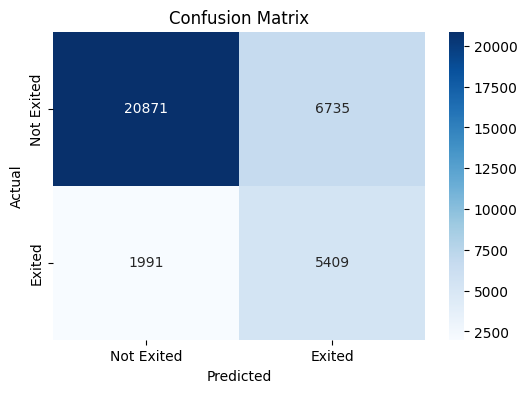

In [15]:
# We already have y_pred from the previous step
# y_pred = logistic_model.predict(X_test)

# --- Classification Report ---
# This provides precision, recall, and F1-score for each class.
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))


# --- Confusion Matrix ---
# This shows exactly where the model made correct and incorrect predictions.
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Optional: Visualize the confusion matrix for better interpretation
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Exited', 'Exited'], 
            yticklabels=['Not Exited', 'Exited'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()